Problem Context and Domain Understanding

The Unaccompanied Alien Children (UAC) Program, managed by the U.S. Department of Health and Human Services (HHS), is responsible for the care and protection of children who enter the United States without a parent or legal guardian. When these children are encountered at the border, they are initially taken into custody by U.S. Customs and Border Protection (CBP). After initial processing, the children are transferred to HHS facilities where they receive shelter, medical care, and case management services until they can be placed with a suitable sponsor, usually a relative or guardian.

Managing this system is challenging because the number of children entering the care system can change rapidly due to factors such as migration trends, policy changes, or humanitarian crises. These fluctuations make it difficult for authorities to plan resources such as shelter capacity, healthcare staff, and caseworkers. If the number of children in care rises suddenly, facilities may become overcrowded and staff may become overburdened.

Currently, most reporting systems focus on describing historical data, which explains what has already happened. However, decision-makers require predictive insights that can estimate future demand for care services. Forecasting the number of children who will be under HHS care in the coming days or weeks can help planners allocate resources proactively, reduce operational stress, and ensure better welfare outcomes for children.

This project aims to build a time-series forecasting system using the UAC dataset to predict future care demand. Specifically, the analysis focuses on forecasting the number of children currently in HHS care, which represents the active care load of the system. In addition, the project examines related system flows such as the number of children transferred from CBP custody and the number of children discharged from HHS care after being placed with sponsors.

By applying time-series analysis and machine learning techniques, this project seeks to transform historical operational data into forward-looking intelligence. The resulting forecasts can serve as an early warning mechanism for potential capacity pressure and support data-driven decision-making in the UAC program.

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/Users/ananyo/Desktop/HHS-PROJECT1/HHS_Unaccompanied_Alien_Children_Program.csv")
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    str    
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    str    
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), str(2)
memory usage: 55.0 KB


In [5]:
df = df.dropna(subset=["Date"])

In [6]:
df["Date"] = pd.to_datetime(df["Date"])

In [7]:
df["Children in HHS Care"] = (
    df["Children in HHS Care"]
    .str.replace(",", "")
    .astype(int)
)

In [8]:
df = df.sort_values("Date")

In [9]:
'''Our target variable is:

Children in HHS Care

This represents active shelter load — exactly what we want to forecast.'''

'Our target variable is:\n\nChildren in HHS Care\n\nThis represents active shelter load — exactly what we want to forecast.'

In [10]:
df["Children in HHS Care"].describe()

count      720.000000
mean      6061.275000
std       2833.070109
min       1972.000000
25%       2467.750000
50%       6406.500000
75%       8010.250000
max      11516.000000
Name: Children in HHS Care, dtype: float64

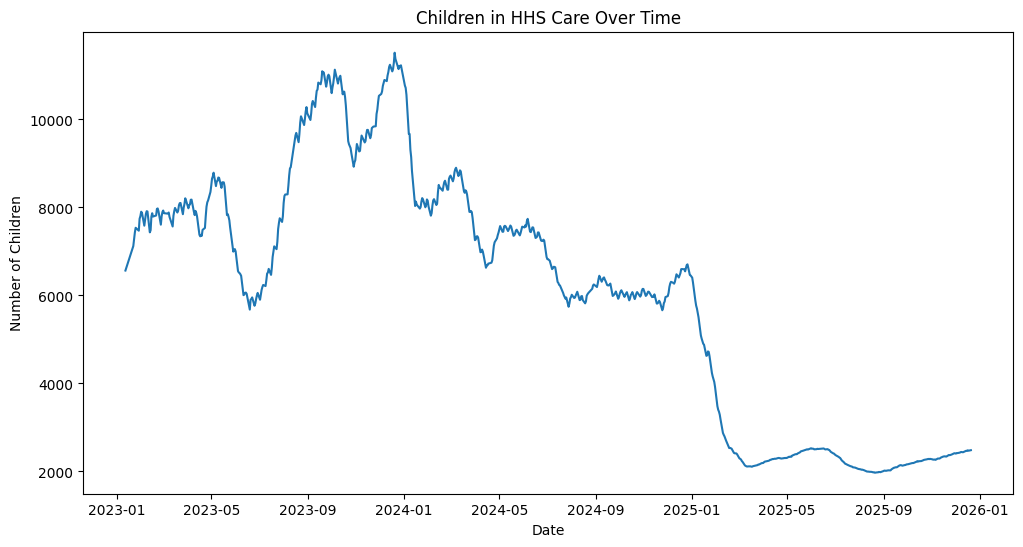

In [11]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Children in HHS Care"])

plt.title("Children in HHS Care Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Children")

plt.show()

In [12]:
df = df.set_index("Date")
df.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33.0,53.0,34.0,6566,436.0
2023-01-22,32.0,49.0,39.0,7122,227.0
2023-01-23,32.0,50.0,39.0,7280,181.0
2023-01-24,47.0,42.0,47.0,7433,175.0
2023-01-25,20.0,22.0,41.0,7538,180.0


In [13]:
df["HHS_7day_avg"] = df["Children in HHS Care"].rolling(window=7).mean()

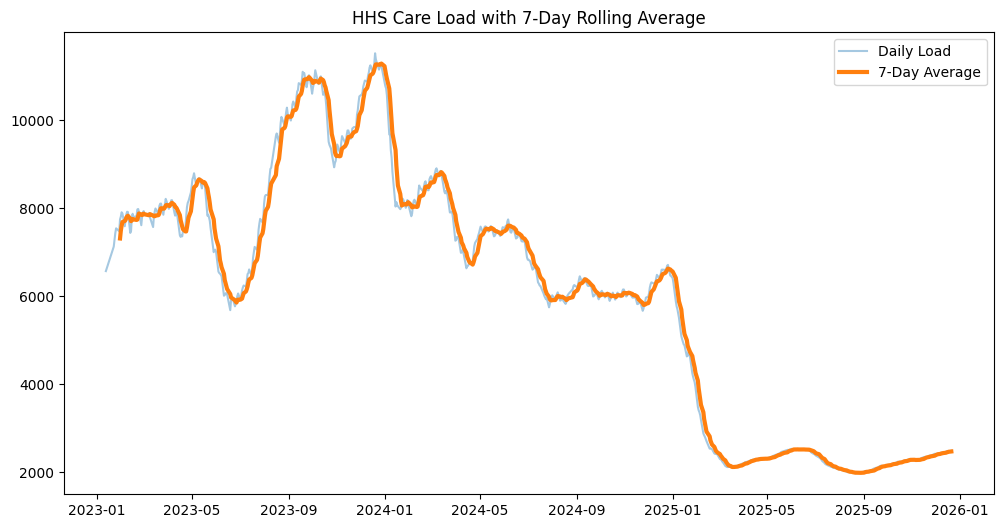

In [14]:
plt.figure(figsize=(12,6))

plt.plot(df["Children in HHS Care"], label="Daily Load", alpha=0.4)
plt.plot(df["HHS_7day_avg"], label="7-Day Average", linewidth=3)

plt.title("HHS Care Load with 7-Day Rolling Average")
plt.legend()

plt.show()

In [15]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 9.5 MB/s  0:00:01eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.7/22.7 MB 9.5 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [statsmodels] [statsmodels]


seasonal decomposition

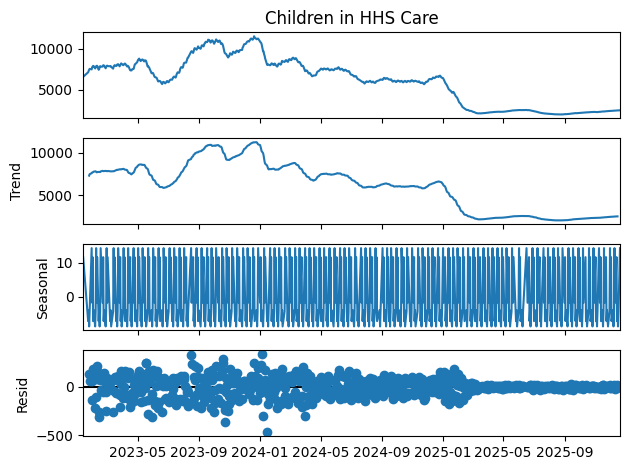

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df["Children in HHS Care"],
    model="additive",
    period=7
)

decomposition.plot()
plt.show()

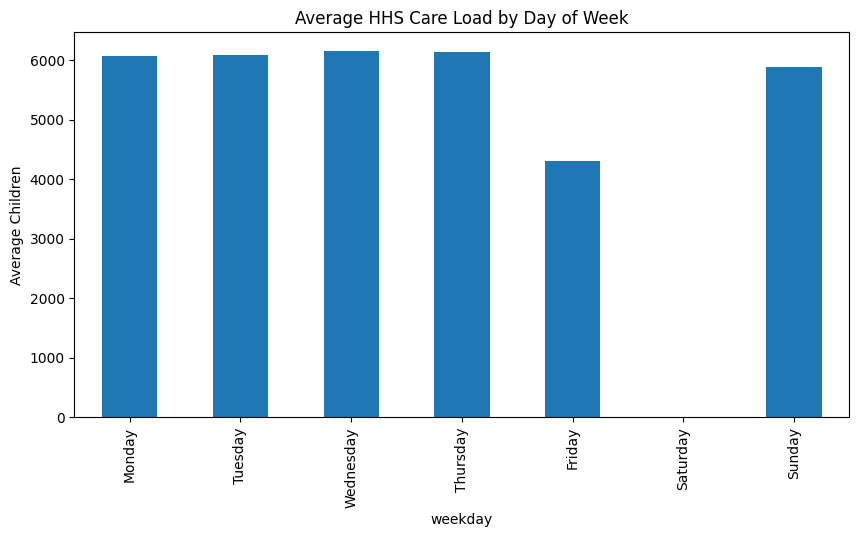

In [17]:
df["weekday"] = df.index.day_name()

weekday_avg = df.groupby("weekday")["Children in HHS Care"].mean()

weekday_avg = weekday_avg.reindex([
    "Monday","Tuesday","Wednesday","Thursday",
    "Friday","Saturday","Sunday"
])

weekday_avg.plot(kind="bar", figsize=(10,5))

plt.title("Average HHS Care Load by Day of Week")
plt.ylabel("Average Children")

plt.show()

Today's shelter load strongly depends on yesterday.

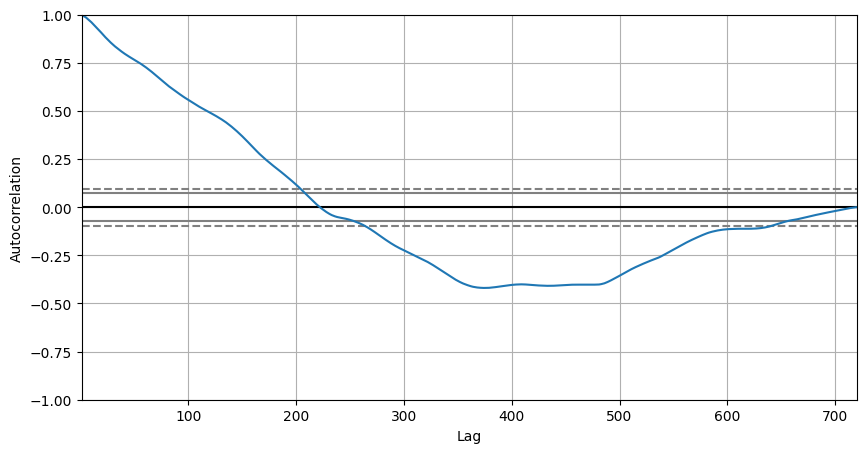

In [18]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(10,5))
autocorrelation_plot(df["Children in HHS Care"])
plt.show()

Feature	Meaning

lag1	= yesterday's population ,

lag7	 = population last week ,

lag14	= population two weeks ago

In [21]:
df["care_lag1"] = df["Children in HHS Care"].shift(1) #.shift(k) moves values down by k days.
df["care_lag7"] = df["Children in HHS Care"].shift(7)
df["care_lag14"] = df["Children in HHS Care"].shift(14)

instead of using the raw values , We take the average of the last 7 days.

Rolling averages capture underlying trend.

In [22]:
df["rolling_mean_7"] = df["Children in HHS Care"].rolling(7).mean()
df["rolling_mean_14"] = df["Children in HHS Care"].rolling(14).mean()

net pressure = transfer - discharge 

If transfers exceed discharges → shelters fill up

If discharges exceed transfers → shelters empty

In [26]:
df["Children transferred out of CBP custody"] = (
    df["Children transferred out of CBP custody"]
    .astype(str)
    .str.replace(",", "")
    .astype(float)
    .astype(int)
)

df["Children discharged from HHS Care"] = (
    df["Children discharged from HHS Care"]
    .astype(str)
    .str.replace(",", "")
    .astype(float)
    .astype(int)
)

df["net_pressure"] = (
    df["Children transferred out of CBP custody"]
    - df["Children discharged from HHS Care"]
)

Pressure can accumulate over time.

So we also create rolling pressure.

In [27]:
df["pressure_7day"] = df["net_pressure"].rolling(7).sum()

In [28]:
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month

In [29]:
# Lag and rolling operations create NaN values at the start.
df = df.dropna()

In [30]:
df.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,HHS_7day_avg,weekday,care_lag1,care_lag7,care_lag14,rolling_mean_7,rolling_mean_14,net_pressure,pressure_7day,day_of_week,month
Date,,,,,,,,,,,,,,,,
2023-02-09,124.0,234.0,161,7908,353,7823.714286,Thursday,7915.0,7803.0,6566.0,7823.714286,7654.071429,-192,-1510.0,3,2
2023-02-12,92.0,203.0,173,7434,317,7756.714286,Sunday,7908.0,7903.0,7122.0,7756.714286,7676.357143,-144,-1450.0,6,2
2023-02-13,186.0,259.0,172,7483,244,7700.142857,Monday,7434.0,7879.0,7280.0,7700.142857,7690.857143,-72,-1247.0,0,2
2023-02-14,154.0,225.0,220,7794,223,7729.857143,Tuesday,7483.0,7586.0,7433.0,7729.857143,7716.642857,-3,-923.0,1,2
2023-02-15,91.0,199.0,172,7869,290,7751.142857,Wednesday,7794.0,7720.0,7538.0,7751.142857,7740.285714,-118,-857.0,2,2


In [31]:
'''Before building complex models like Random Forest or ARIMA, we must answer:

Is forecasting even better than a simple guess?

So we start with a Naive Persistence Model.'''

'Before building complex models like Random Forest or ARIMA, we must answer:\n\nIs forecasting even better than a simple guess?\n\nSo we start with a Naive Persistence Model.'

naive forecast 
prediction t = actual t-1
 means tomorrow will be the same day as today

In [32]:
# this works surprisingly well:

# many time series change slowly

# yesterday is often the best short-term predictor

In [34]:
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

Prediction today = yesterday's actual value

In [35]:
test["naive_prediction"] = test["Children in HHS Care"].shift(1)

In [36]:
test.iloc[0, test.columns.get_loc("naive_prediction")] = train["Children in HHS Care"].iloc[-1]

In [41]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 10.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [42]:
# evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = test["Children in HHS Care"]
y_pred = test["naive_prediction"]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 10.422535211267606
RMSE: 14.207714627257175
MAPE: 0.46073663869353787


In [43]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [44]:
# adf test 
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Children in HHS Care"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.9421281059536997
p-value: 0.7737827598666874


p = 0.773

This is much greater than 0.05, so:

We fail to reject the null hypothesis

Meaning:

The series is NON-STATIONARY

This makes sense given the dataset.

Remember the trend we saw earlier:

~2000 → ~11000 → ~3000

The mean changes over time, which violates stationarity.

Typical causes here:

• migration waves
• policy changes
• shelter expansions

In [45]:
# we must transform the data.

In [46]:
# We remove the trend by calculating change between days.
# Yt = yt - yt-1
# care_diff = representing daily population change.

df["care_diff"] = df["Children in HHS Care"].diff()

In [47]:
df_diff = df["care_diff"].dropna()

In [48]:
result = adfuller(df_diff)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -5.298207335073643
p-value: 5.522666094962839e-06


In [53]:
from statsmodels.tsa.arima.model import ARIMA

# train model
model = ARIMA(train["Children in HHS Care"], order=(1,1,1))

model_fit = model.fit()

print(model_fit.summary())
df = df.asfreq("D")

                                SARIMAX Results                                 
Dep. Variable:     Children in HHS Care   No. Observations:                  564
Model:                   ARIMA(1, 1, 1)   Log Likelihood               -3608.023
Date:                  Mon, 16 Mar 2026   AIC                           7222.046
Time:                          19:53:41   BIC                           7235.045
Sample:                               0   HQIC                          7227.121
                                  - 564                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0345      0.238      0.145      0.885      -0.433       0.502
ma.L1          0.1494      0.236      0.634      0.526      -0.313       0.611
sigma2      2.152e+04    712.920    

/Users/ananyo/Desktop/HHS-PROJECT1/.hhsvenv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ananyo/Desktop/HHS-PROJECT1/.hhsvenv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ananyo/Desktop/HHS-PROJECT1/.hhsvenv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [55]:
forecast = model_fit.forecast(steps=len(test))

test["arima_forecast"] = forecast.values

/Users/ananyo/Desktop/HHS-PROJECT1/.hhsvenv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ananyo/Desktop/HHS-PROJECT1/.hhsvenv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [56]:
test[["Children in HHS Care", "arima_forecast"]].isna().sum()


Children in HHS Care    0
arima_forecast          0
dtype: int64

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = test["Children in HHS Care"]
y_pred = test["arima_forecast"]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("ARIMA MAE:", mae)
print("ARIMA RMSE:", rmse)
print("ARIMA MAPE:", mape)

ARIMA MAE: 197.55578195299793
ARIMA RMSE: 241.43059492683625
ARIMA MAPE: 9.310805655138092


In [58]:
# Naive error ≈ 10 children
# ARIMA error ≈ 197 children
# ARIMA model performs much worse than the naive model.


This happens because your series behaves almost like a random walk.

Mathematically:

Y(t) ≈ Y(t-1)

Meaning:

The best prediction for tomorrow is simply today's value.

This is exactly what the naive model assumes.

ARIMA tries to learn patterns like:
Y(t) = a * Y(t-1) + error(t-1)

ARIMA only uses:

past values of the target

But your dataset contains system drivers:

Variable	Meaning
Children transferred	inflow
Children discharged	outflow
Net pressure	system stress

These are causal signals.

Example:

Transfers spike today
→ population will increase tomorrow

ARIMA cannot see that.

But ML models can.

In [59]:
features = [
    "care_lag1",
    "care_lag7",
    "care_lag14",
    "rolling_mean_7",
    "rolling_mean_14",
    "net_pressure",
    "pressure_7day",
    "day_of_week",
    "month"
]

In [60]:
# target variables 
target = "Children in HHS Care"

In [61]:
# training data 
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

train random forest 

In [62]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [65]:
# Make Predictions 

In [63]:
test["rf_forecast"] = rf_model.predict(X_test)

Evaluate Random Forest

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = test[target]
y_pred = test["rf_forecast"]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("RF MAE:", mae)
print("RF RMSE:", rmse)
print("RF MAPE:", mape)

RF MAE: 60.38599229721766
RF RMSE: 81.68390324151154
RF MAPE: 2.7914650445144664


The best model is still the Naive model.


Because:
MAPE = 0.46%

Which is far smaller than:

Random Forest = 2.79%
So  dataset behaves like a high-inertia time series where:

Population tomorrow ≈ population today

This is very common in capacity / inventory systems.

Random Forest Didn't Beat Naive

Even though Random Forest uses:

net_pressure
rolling means
lag features

the system still changes very slowly.



Even if naive predicts the level well, it cannot detect risk events.

most impactful part of the project.

Instead of predicting only the number of children, we estimate:

Probability that shelter capacity will be exceeded

In [66]:
# Define Capacity Threshold
capacity_limit = 10000
df["capacity_breach"] = (
    df["Children in HHS Care"] > capacity_limit
).astype(int)

Train Breach Classifier

In [68]:
capacity_limit = 10000

df["capacity_breach"] = (
    df["Children in HHS Care"] > capacity_limit
).astype(int)

In [72]:
train = df[:train_size]
test = df[train_size:]

In [73]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

clf.fit(X_train, train["capacity_breach"])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [75]:
features = [
    "care_lag1",
    "care_lag7",
    "care_lag14",
    "rolling_mean_7",
    "rolling_mean_14",
    "net_pressure",
    "pressure_7day",
    "day_of_week",
    "month"
]

target = "Children in HHS Care"

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [76]:
print(len(X_test))
print(len(test))

483
483


In [77]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

clf.fit(X_train, train["capacity_breach"])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [78]:
test["breach_probability"] = clf.predict_proba(X_test)[:,1]

In [79]:
test[[
    "Children in HHS Care",
    "breach_probability"
]].head(10)

,Children in HHS Care,breach_probability
Date,,
2024-08-26,NaN,0.000
2024-08-27,6152.0,0.000
2024-08-28,6227.0,0.000
2024-08-29,6250.0,0.000
2024-08-30,NaN,0.000
2024-08-31,NaN,0.000
2024-09-01,NaN,0.000
2024-09-02,6192.0,0.005
2024-09-03,6272.0,0.005
